# Qualitative features notebook

## Generating test data

In [ ]:
import os
# Specify the desired number of images
desired_count = 100

# Generate images one by one until the desired count is reached
while True:
    !python3 ../samples_generator/samples_generator.py --num_images 5 --img_size 500 --specified_angle 90 --output_dir ../../tests/generated_samples/triangle/
    !python3 ../line_detector/line_detector.py --folder_path ../../tests/generated_samples/triangle/

    # Check the number of files in the folder
    path, dirs, files = next(os.walk("../../tests/generated_samples/triangle/"))
    file_count = len(files)
    print(f"Total images: {file_count}")

    # Break the loop if the desired count is reached
    if file_count >= desired_count:
        break

print(f"Number of test images: {file_count}")

### Generate squares

In [1]:
import os
# Specify the desired number of images
desired_count = 100

# Generate images one by one until the desired count is reached
while True:
    !python3 ../samples_generator/square_generator.py --num_images 10 --img_size 500 --output_dir ../../tests/generated_samples/square/
    !python3 ../line_detector/line_detector.py --folder_path ../../tests/generated_samples/square/ --num_lines 4

    # Check the number of files in the folder
    path, dirs, files = next(os.walk("../../tests/generated_samples/square/"))
    file_count = len(files)
    print(f"Total images: {file_count}")

    # Break the loop if the desired count is reached
    if file_count >= desired_count:
        break

print(f"Number of test images: {file_count}")

Total images: 2
Total images: 3
Total images: 4
Total images: 5
Total images: 6
Total images: 6
Total images: 7
Total images: 8
Total images: 9
Total images: 10
Total images: 10
Total images: 11
Total images: 12
Total images: 13
Total images: 14
Total images: 14
Total images: 15
Total images: 16
Total images: 17
Total images: 18
Total images: 18
Total images: 19
Total images: 20
Total images: 21
Total images: 22
Total images: 22
Total images: 23
Total images: 24
Total images: 25
Total images: 26
Total images: 26
Total images: 27
Total images: 28
Total images: 29
Total images: 30
Total images: 30
Total images: 31
Total images: 32
Total images: 33
Total images: 34
Total images: 34
Total images: 35
Total images: 36
Total images: 37
Total images: 38
Total images: 38
Total images: 39
Total images: 40
Total images: 41
Total images: 42
Total images: 42
Total images: 43
Total images: 44
Total images: 45
Total images: 46
Total images: 46
Total images: 47
Total images: 48
Total images: 49
Total 

### Generate squares

In [ ]:
import os

# Generate 500 images of size 100x100
!python3 ../samples_generator/square_generator.py --num_images 10 --img_size 250 --output_dir ../../tests/squares/

## Analyze training results

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('../../training_results/qualitative_features.csv')

# Ensure node_id is a string to prevent any unintended type interpretations
df['node_id'] = df['node_id'].astype(str)
df['labels'] = df['labels'].astype(str)  # Ensure labels are treated as string

# Combine 'node_id' and 'labels' for a unique identifier and legend information
df['node_label'] = df['node_id'] + " - " + df['labels']

# Get the latest (or max) relation count for each node_label to order the legend
latest_relation_count = df.groupby('node_label')['relation_count'].max().sort_values(ascending=False)

# Create a sorted list of node_labels based on the latest relation count
sorted_node_labels = latest_relation_count.index.tolist()

# Pivot the DataFrame to have iterations as index and each unique node_label as a column
pivot_df = df.pivot_table(index='iteration', columns='node_label', values='relation_count', aggfunc='max')

# Reorder pivot_df columns based on the sorted node_labels
pivot_df = pivot_df[sorted_node_labels]

# Plotting
fig, ax = plt.subplots(figsize=(12, 12))

# Plot and use the colormap for a wider variety of colors
pivot_df.plot(kind='line', ax=ax, cmap='tab10')

# Title and labels
plt.title('Number of Inbound Links per Node Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Inbound Links')

# Adjust legend - Since we have combined node_id and labels, it will show both
plt.legend(title='Node ID - Label', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to accommodate the legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()

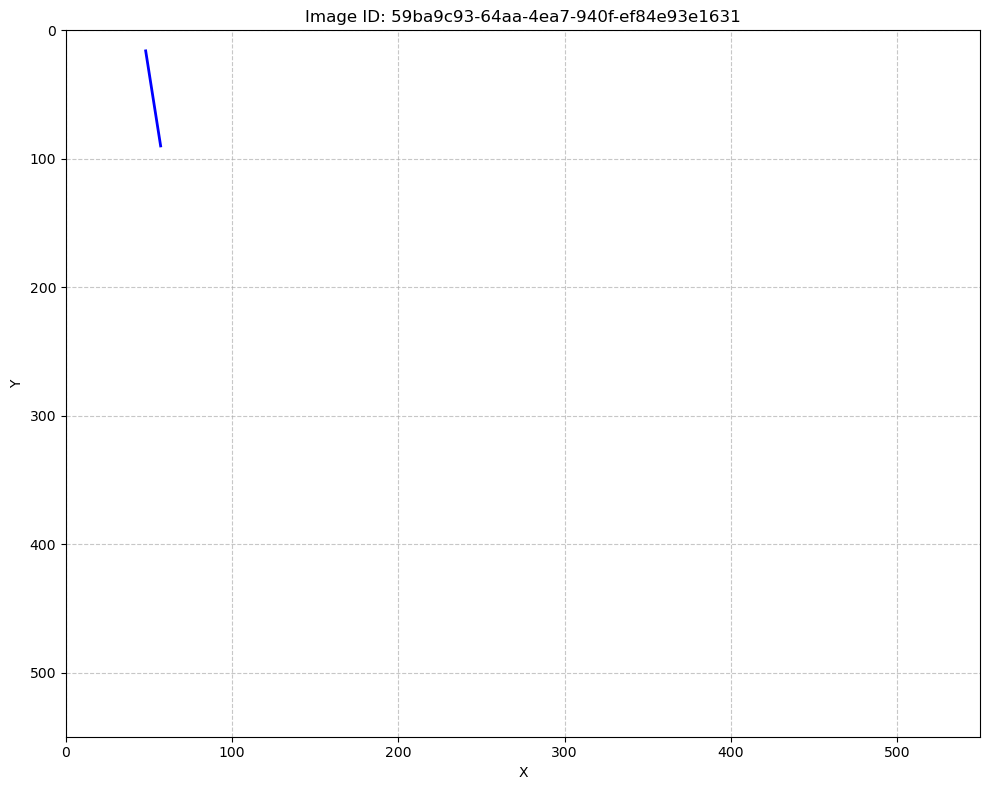

In [3]:
import json
import matplotlib.pyplot as plt
import math

# Your JSON data as a string (remove the timestamps)
json_str = '''
{
	"operation": "train",
	"image_id": "59ba9c93-64aa-4ea7-940f-ef84e93e1631",
	"lines": [
		{
			"id": "a7b7f7e0-9f57-40f5-8c2a-64e6c523335c",
			"x1": 48,
			"y1": 16,
			"x2": 57,
			"y2": 90,
			"length": 74
		}
	],
	"parameters": {
		"concept_name": "mnist_one",
		"image_path": "/opt/nuclio/shared_storage/mnist_ones/mnist_one_00003.png",
		"session_id": "d01e0791-9903-4b27-8a22-0b6cfde490a5"
	},
	"angle_points": []
}
'''

# Parse the JSON data
data = json.loads(json_str)

# Create a new figure
plt.figure(figsize=(10, 8))

# Function to calculate angle between two lines
def calculate_angle(line1, line2):
    dx1 = line1['x2'] - line1['x1']
    dy1 = line1['y2'] - line1['y1']
    dx2 = line2['x2'] - line2['x1']
    dy2 = line2['y2'] - line2['y1']
    
    angle1 = math.atan2(dy1, dx1)
    angle2 = math.atan2(dy2, dx2)
    
    angle = abs(angle1 - angle2)
    angle = min(angle, 2*math.pi - angle)
    return math.degrees(angle)

# Plot lines and calculate all angles
lines = data['lines']
for i, line in enumerate(lines):
    plt.plot([line['x1'], line['x2']], [line['y1'], line['y2']], 'b-', linewidth=2)
    
    for j, other_line in enumerate(lines[i+1:], start=i+1):
        angle = calculate_angle(line, other_line)
        mid_x = (line['x1'] + line['x2'] + other_line['x1'] + other_line['x2']) / 4
        mid_y = (line['y1'] + line['y2'] + other_line['y1'] + other_line['y2']) / 4
        plt.text(mid_x, mid_y, f"{angle:.1f}°", fontsize=8, ha='center', va='center', color='gray')

# Plot angle points from JSON
for point in data['angle_points']:
    plt.plot(point['x'], point['y'], 'ro', markersize=8)
    plt.text(point['x'], point['y'], f"{point['angle']}°", fontsize=10, ha='right', va='bottom', color='red')

# Set the axis limits
plt.xlim(0, 550)
plt.ylim(0, 550)

# Invert the y-axis to match image coordinates
plt.gca().invert_yaxis()

# Add labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f"Image ID: {data['image_id']}")

# Add a grid
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
import json
import math
import numpy as np

# Your JSON data as a string
json_str = '''
{
	"image_id": "e4f541c5-820a-4993-b7a0-70eaed20aab5",
	"lines": [
		{
			"id": "fb5a3534-2faf-425b-88e7-afc4a1518941",
			"x1": 0,
			"y1": 345,
			"x2": 454,
			"y2": 16,
			"length": 560
		},
		{
			"id": "38ead634-3101-4ad2-9565-c8b1e40bb8d2",
			"x1": 1,
			"y1": 294,
			"x2": 499,
			"y2": 373,
			"length": 504
		},
		{
			"id": "bdc2fe4d-2046-4a7a-9cdb-5f739927d3a8",
			"x1": 373,
			"y1": 0,
			"x2": 326,
			"y2": 498,
			"length": 500
		}
	]
 }
'''

# Parse the JSON data
data = json.loads(json_str)

# Extract the lines from the data
lines = data['lines']

# Function to calculate the angle between two lines
def calculate_angle(line1: dict, line2: dict) -> float:
    dx1 = line1['x2'] - line1['x1']
    dy1 = line1['y2'] - line1['y1']
    dx2 = line2['x2'] - line2['x1']
    dy2 = line2['y2'] - line2['y1']
    
    dot_product = dx1 * dx2 + dy1 * dy2
    magnitude1 = math.sqrt(dx1**2 + dy1**2)
    magnitude2 = math.sqrt(dx2**2 + dy2**2)
    
    angle_rad = math.acos(dot_product / (magnitude1 * magnitude2))
    angle_deg = math.degrees(angle_rad)
    
    return angle_deg

# Calculate the angles between each pair of lines
angles = []
for i in range(len(lines)):
    for j in range(i+1, len(lines)):
        angle = calculate_angle(lines[i], lines[j])
        angles.append(angle)

# Print the calculated angles
print("Angles of the triangle:")
for angle in angles:
    print(f"{angle:.2f} degrees")